# Notebook 1 — Le perceptron, à la main

**TP « Du perceptron au MLP » · ~45 min**

### Ce que tu sauras faire à la fin

1. Écrire un perceptron complet en NumPy : `z = w · x + b`, puis une fonction seuil.
2. Coder la règle de mise à jour vue ce matin (slide 3.6) et la faire tourner.
3. Montrer **expérimentalement** pourquoi le perceptron échoue sur XOR — et pourquoi il
   réussit sur « 0 contre 1 ».
4. **Regarder** les poids appris. Ils forment une image.

> Tout le code de ce notebook utilise la notation du matin : `x`, `w`, `b`, `z`, `y_chapeau`,
> `eta`. Chaque ligne doit pouvoir être pointée sur une slide.

In [1]:
import pathlib
import sys

# On retrouve la racine du dépôt, qu'on lance ce notebook depuis notebooks/
# ou depuis notebooks/solutions/.
RACINE = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "src" / "mnist.py").exists())
sys.path.insert(0, str(RACINE / "src"))

import numpy as np
import matplotlib.pyplot as plt

import viz
from couleurs import applique_style, BLEU, VIOLET

applique_style()
np.random.seed(0)   # pour que ton écran affiche la même chose que le vidéoprojecteur

---
# Partie A — XOR : là où la matinée s'est arrêtée

Slide 4.2. Le tableau de vérité de XOR (« ou exclusif ») : la sortie vaut 1 quand
**exactement une** des deux entrées vaut 1.

| x₁ | x₂ | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

Quatre points. Pas de téléchargement, pas de dataset. On va essayer d'apprendre ça avec
un perceptron, et regarder très précisément ce qui se passe.

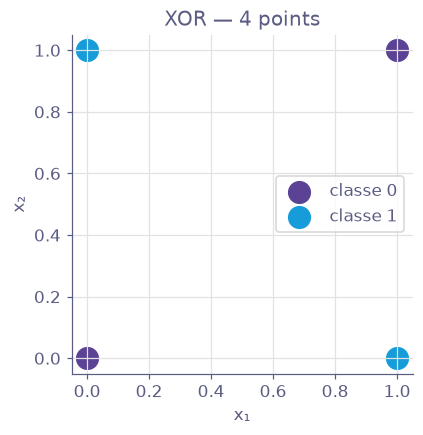

In [2]:
X_xor = np.array([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]])
y_xor = np.array([0, 1, 1, 0])

plt.figure(figsize=(4, 4))
for classe, couleur in [(0, VIOLET), (1, BLEU)]:
    points = X_xor[y_xor == classe]
    plt.scatter(points[:, 0], points[:, 1], c=couleur, s=200, label=f"classe {classe}")
plt.xlabel("x₁"); plt.ylabel("x₂"); plt.title("XOR — 4 points")
plt.legend(); plt.show()

### Pourquoi ?

Prends 10 secondes et essaie de tracer **une seule droite** qui met les deux points bleus
d'un côté et les deux violets de l'autre.

C'est impossible. Mais on ne va pas se contenter de le dire : on va le faire subir à un
perceptron.

## A.1 — La fonction seuil (slide 3.3)

$$\hat{y} = f(z) = \begin{cases} 1 & \text{si } z \geq 0 \\ 0 & \text{sinon}\end{cases}
\qquad \text{avec} \qquad z = w \cdot x + b$$

Deux fonctions à écrire. `seuil` applique la marche de Heaviside ; `predit` fait la somme
pondérée puis le seuil.

In [3]:
def seuil(z):
    """Fonction de Heaviside : 1 si z >= 0, 0 sinon. Marche aussi sur un tableau."""
    return np.where(z >= 0, 1, 0)


def predit(x, w, b):
    """Prédiction du perceptron pour un exemple x (ou un lot d'exemples)."""
    z = x @ w + b
    return seuil(z)


# Vérification rapide : avec ces poids, le neurone doit répondre au OU logique.
w_test = np.array([1.0, 1.0])
b_test = -0.5
assert list(predit(X_xor, w_test, b_test)) == [0, 1, 1, 1], "revois seuil() ou predit()"
print("OK — ce neurone-là calcule le OU logique (pas encore XOR).")

OK — ce neurone-là calcule le OU logique (pas encore XOR).


## A.2 — La règle de mise à jour (slide 3.6)

$$w_{\text{nouveau}} = w_{\text{ancien}} + \eta \cdot (y - \hat{y}) \cdot x
\qquad
b_{\text{nouveau}} = b_{\text{ancien}} + \eta \cdot (y - \hat{y})$$

Les trois cas de la slide :

- **Bonne prédiction** → `y - y_chapeau = 0` → rien ne bouge.
- **Faux négatif** (on attendait 1, on a prédit 0) → l'écart vaut +1 → on **augmente** `w`.
- **Faux positif** (on attendait 0, on a prédit 1) → l'écart vaut −1 → on **diminue** `w`.

Le code ci-dessous doit être superposable à la formule. Littéralement la même ligne.

In [4]:
def entraine_perceptron(X, y, eta=0.1, epoques=20, trace=False):
    """Entraîne un perceptron. Renvoie (w, b, erreurs_par_epoque)."""
    w = np.zeros(X.shape[1])
    b = 0.0
    erreurs = []

    for epoque in range(epoques):
        n_erreurs = 0
        for x, y_vrai in zip(X, y):
            y_chapeau = predit(x, w, b)

            w = w + eta * (y_vrai - y_chapeau) * x
            b = b + eta * (y_vrai - y_chapeau)

            n_erreurs += int(y_chapeau != y_vrai)
        erreurs.append(n_erreurs)
        if trace:
            print(f"époque {epoque:3d} — {n_erreurs} erreur(s) — w={w.round(2)} b={b:.2f}")

    return w, b, erreurs

In [5]:
w, b, erreurs = entraine_perceptron(X_xor, y_xor, eta=0.1, epoques=15, trace=True)

époque   0 — 3 erreur(s) — w=[-0.1  0. ] b=-0.10
époque   1 — 3 erreur(s) — w=[-0.1  0. ] b=0.00
époque   2 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque   3 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque   4 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque   5 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque   6 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque   7 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque   8 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque   9 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque  10 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque  11 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque  12 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque  13 — 4 erreur(s) — w=[-0.1  0. ] b=0.00
époque  14 — 4 erreur(s) — w=[-0.1  0. ] b=0.00


### Ce qu'on vient de voir

Le nombre d'erreurs **ne descend jamais à 0**. Il oscille. `w` bouge, revient, repart —
sans jamais se stabiliser. Ce n'est pas un bug, ce n'est pas un `eta` mal réglé : il
n'existe aucun couple (`w`, `b`) qui satisfasse les 4 points à la fois.

Regardons la frontière que le perceptron a fini par proposer.

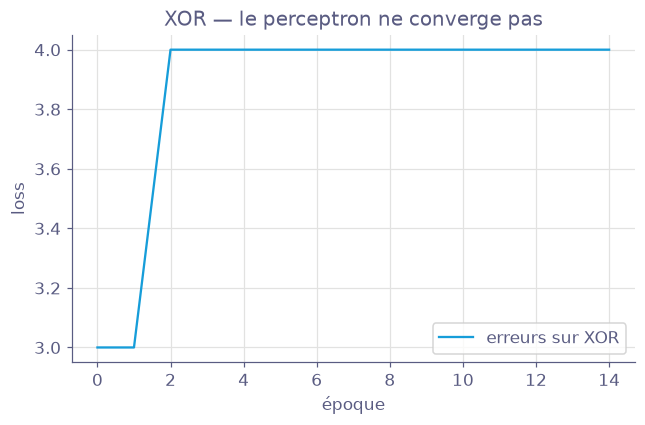

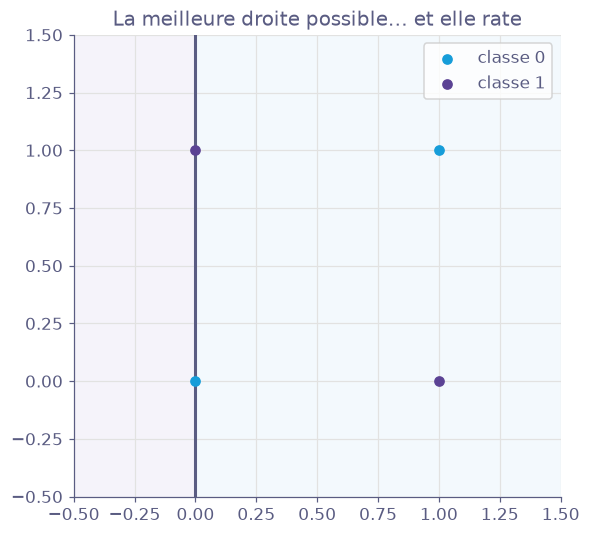

In [6]:
viz.plot_courbes({"erreurs sur XOR": erreurs}, titre="XOR — le perceptron ne converge pas")
viz.montre_frontiere(X_xor, y_xor, w, b, titre="La meilleure droite possible… et elle rate")

> ### ✏️ À toi de jouer
>
> Relance l'entraînement avec `eta=0.5` puis `epoques=500`. Le résultat change-t-il ?
> Écris en une phrase, dans la cellule suivante, **pourquoi** ça ne peut pas marcher.

In [7]:
# Fais tes essais ici.
w2, b2, erreurs2 = entraine_perceptron(X_xor, y_xor, eta=0.5, epoques=500)
print("erreurs sur les 10 dernières époques :", erreurs2[-10:])

erreurs sur les 10 dernières époques : [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


**Ta réponse :** *(double-clique pour éditer)*

> …

**La réponse attendue :** un perceptron trace **une seule droite** (slide 3.4). XOR n'est
pas linéairement séparable (slide 4.1). Aucun réglage de `eta` ou d'`epoques` ne peut
contourner ça — c'est une limite de la *forme* du modèle, pas de son entraînement.

C'est exactement l'argument du **tir à l'arc** (slide 4.3) : une seule règle de correction
ne suffit pas. Il en faut plusieurs, combinées. → notebook 2.

---
# Partie B — MNIST : là où le perceptron réussit

Une droite ne suffit pas pour XOR. Mais pour distinguer un **0** d'un **1** ? Essayons.

## B.1 — Regarder les données avant de les utiliser

La plupart des tutoriels MNIST cachent cette étape dans un `transform`. On va faire
l'inverse : chaque transformation sera une décision visible, et justifiée.

In [8]:
import mnist

X_train, y_train, X_test, y_test = mnist.charge_mnist(aplati=False, normalise=False)

print("X_train :", X_train.shape, X_train.dtype)
print("y_train :", y_train.shape, y_train.dtype)
print("valeurs des pixels : de", X_train.min(), "à", X_train.max())
print("répartition des classes :", np.bincount(y_train))

X_train : (60000, 28, 28) float32
y_train : (60000,) int64
valeurs des pixels : de 0.0 à 255.0
répartition des classes : [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


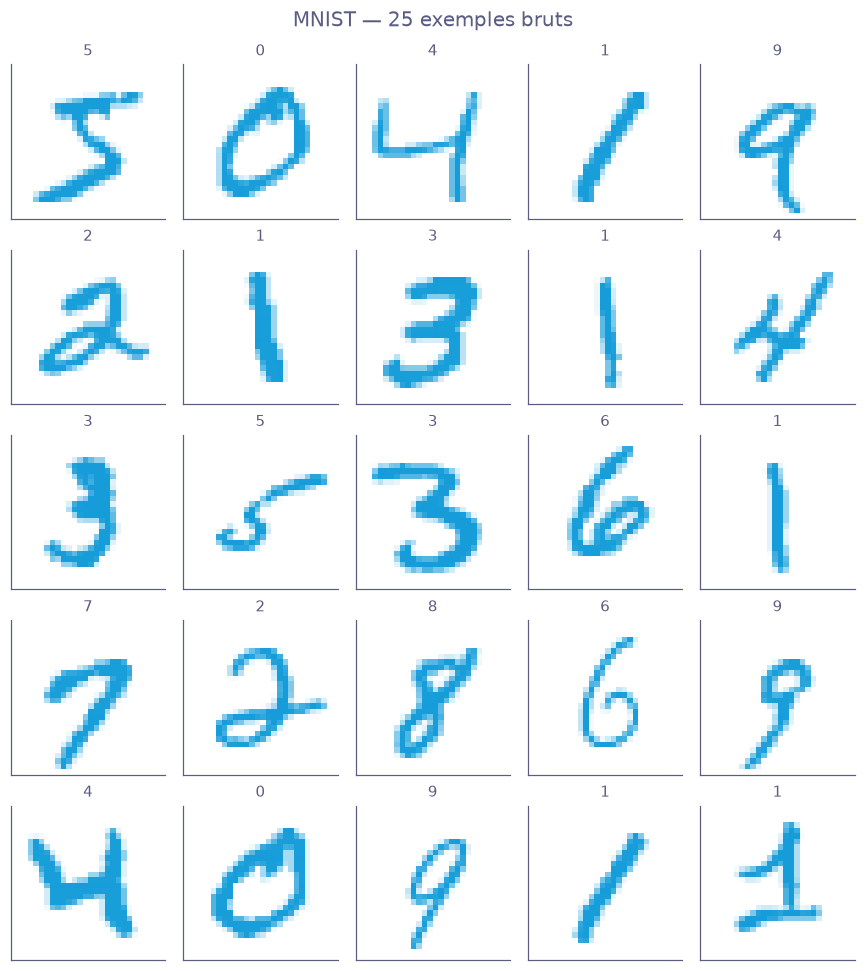

In [9]:
viz.affiche_chiffres(X_train, y_train, n=25, titre="MNIST — 25 exemples bruts")

### Pourquoi aplatir en 784 ?

Le neurone de la **slide 2.1** mange un **vecteur** `x`, pas une grille. Il faut donc
mettre les 28×28 pixels bout à bout : `28 × 28 = 784`.

C'est aussi le 784 de la **slide 5.5** (celle du décompte des paramètres) — ce n'est pas
un nombre magique, c'est juste la taille d'une image MNIST dépliée.

⚠️ **Retiens cette ligne.** On reviendra l'accuser au notebook 4 : en aplatissant, on
détruit toute l'information « quel pixel est à côté de quel pixel ». Le réseau ne saura
jamais que c'était une image.

### Pourquoi diviser par 255 ?

Réponse habituelle : « parce qu'il faut normaliser ». Ça n'explique rien. On va le
**mesurer** — à la fin de la partie B, avec et sans.

L'intuition, ancrée sur la **slide 6.4** : le pas de mise à jour vaut `eta · (y - ŷ) · x`.
Il est **proportionnel à x**. Avec des pixels à 255, les pas sont 255 fois plus grands que
prévu et le modèle saute par-dessus la solution.

### Pourquoi un jeu de test qu'on ne touche jamais ?

Pour mesurer si le modèle **généralise**, pas s'il a **mémorisé**. On l'utilisera une fois,
à la fin. C'est tout.

## B.2 — Le sous-problème « 0 contre 1 »

Le perceptron ne sait faire qu'une classification **binaire** (slide 3.2). On ne garde donc
que les 0 et les 1.

In [10]:
X_train01, y_train01, X_test01, y_test01 = mnist.charge_mnist(
    aplati=True, normalise=True, sous_ensemble=[0, 1]
)

print("train :", X_train01.shape, "— test :", X_test01.shape)
print("valeurs des pixels : de", X_train01.min(), "à", X_train01.max())
print("étiquettes présentes :", np.unique(y_train01))

train : (12665, 784) — test : (2115, 784)
valeurs des pixels : de 0.0 à 1.0
étiquettes présentes : [0 1]


accuracy sur le jeu de test : 99.95%


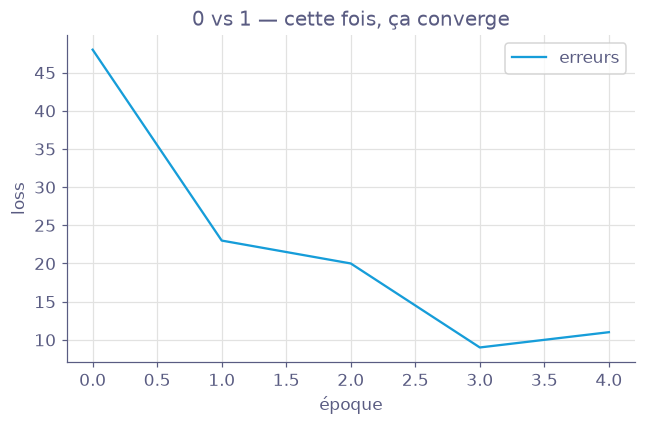

In [11]:
w01, b01, erreurs01 = entraine_perceptron(X_train01, y_train01, eta=0.01, epoques=5)

y_chapeau_test = predit(X_test01, w01, b01)
accuracy = (y_chapeau_test == y_test01).mean()
print(f"accuracy sur le jeu de test : {accuracy:.2%}")
assert accuracy > 0.99, "on attend plus de 99 % ici"

viz.plot_courbes({"erreurs": erreurs01}, titre="0 vs 1 — cette fois, ça converge")

## B.3 — Le moment important : regarder `w`

`w` a 784 composantes. Une par pixel. Donc `w` **se replie en une image 28×28**.

C'est la chose la plus utile de tout ce notebook : les poids ne sont pas une abstraction,
ce sont des pixels. Le perceptron a appris un **gabarit**.

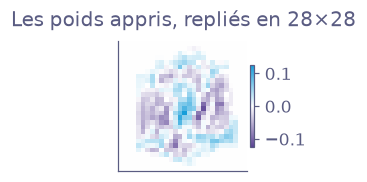

In [12]:
viz.montre_poids(w01, titre="Les poids appris, repliés en 28×28")

### Comment lire cette image

- **Bleu** = poids positif : « de l'encre ici pousse vers la classe 1 » → on voit la barre
  verticale du **1**.
- **Violet** = poids négatif : « de l'encre ici pousse vers la classe 0 » → on devine
  l'anneau du **0**.
- **Blanc** = poids ≈ 0 : ces pixels-là ne servent à rien (les bords, toujours noirs).

`w · x` est donc juste une **mesure de ressemblance** entre l'image et ce gabarit. C'est
tout ce que fait un neurone.

## B.4 — L'expérience `/255` : normalisé contre non normalisé

Maintenant, la preuve promise plus haut. Même code, mêmes époques, même `eta`. Seule
différence : les pixels vont de 0 à 255 au lieu de 0 à 1.

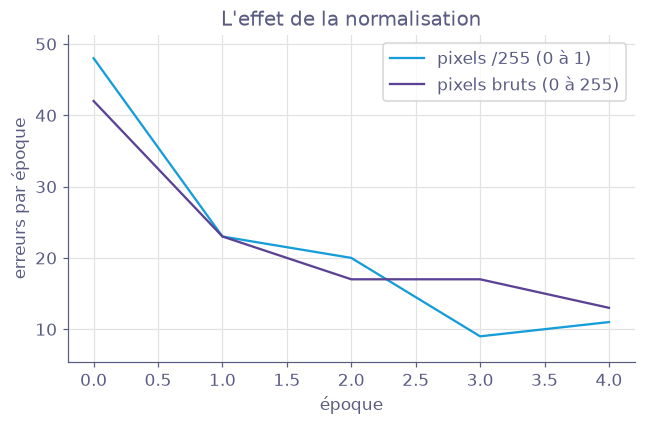

dernière époque — normalisé : 11 | brut : 13


In [13]:
X_brut, y_brut, _, _ = mnist.charge_mnist(aplati=True, normalise=False, sous_ensemble=[0, 1])

_, _, erreurs_normalise = entraine_perceptron(X_train01, y_train01, eta=0.01, epoques=5)
_, _, erreurs_brut = entraine_perceptron(X_brut, y_brut, eta=0.01, epoques=5)

viz.plot_comparaison(
    {"pixels /255 (0 à 1)": erreurs_normalise, "pixels bruts (0 à 255)": erreurs_brut},
    titre="L'effet de la normalisation",
    ylabel="erreurs par époque",
)
print("dernière époque — normalisé :", erreurs_normalise[-1], "| brut :", erreurs_brut[-1])

### À retenir

`/255` n'est pas une incantation copiée d'un tutoriel. C'est un **réglage d'échelle du pas
d'apprentissage**, et on vient de le mesurer.

## B.5 — Le mur

0 contre 1, c'est facile : ces deux chiffres ne se ressemblent pas. Essayons deux chiffres
qui se ressemblent.

### Un détail qui compte : traduire les étiquettes

`charge_mnist` renvoie les **vrais** chiffres comme étiquettes : pour la paire `[3, 5]`,
`y` contient des 3 et des 5. Or le perceptron ne sait répondre que **0 ou 1**.

Il faut donc traduire avant d'entraîner : le plus petit chiffre devient la classe 0, l'autre
la classe 1. Si on oublie, la règle `w += eta · (y − ŷ) · x` reçoit un écart de `5 − 1 = 4`
au lieu de `1 − 0 = 1`, et l'entraînement part n'importe où.

(Pour `[0, 1]`, la traduction ne changeait rien — les étiquettes valaient déjà 0 et 1.
C'est le genre de bug qui se cache très bien.)

In [14]:
def en_binaire(y, paire):
    """Traduit les étiquettes : le plus petit chiffre -> 0, l'autre -> 1."""
    return (y == max(paire)).astype(int)


for paire in ([0, 1], [3, 5], [4, 9]):
    Xa, ya, Xb, yb = mnist.charge_mnist(aplati=True, normalise=True, sous_ensemble=paire)
    wp, bp, _ = entraine_perceptron(Xa, en_binaire(ya, paire), eta=0.01, epoques=5)
    score = (predit(Xb, wp, bp) == en_binaire(yb, paire)).mean()
    print(f"{paire[0]} contre {paire[1]} : {score:.2%}")

0 contre 1 : 99.95%


3 contre 5 : 91.80%


4 contre 9 : 96.28%


> ### ✏️ À toi de jouer
>
> Trouve la paire de chiffres que le perceptron confond **le plus**. Affiche ensuite
> quelques images qu'il rate, avec `viz.affiche_chiffres(..., predictions=...)`.

la pire paire : 2 contre 8 — 80.01%


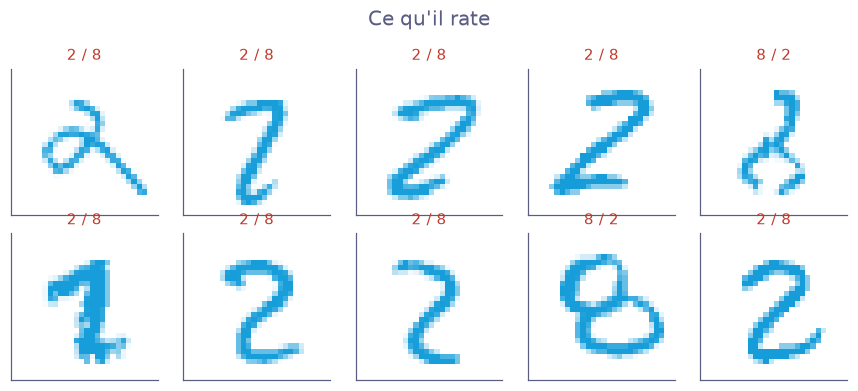

In [15]:
pires = []
for a in range(10):
    for c in range(a + 1, 10):
        Xa, ya, Xb, yb = mnist.charge_mnist(aplati=True, normalise=True, sous_ensemble=[a, c])
        # 2000 exemples et 2 époques suffisent pour classer les paires entre elles.
        wp, bp, _ = entraine_perceptron(Xa[:2000], en_binaire(ya[:2000], [a, c]),
                                        eta=0.01, epoques=2)
        pires.append(((predit(Xb, wp, bp) == en_binaire(yb, [a, c])).mean(), a, c))

score, a, c = min(pires)
print(f"la pire paire : {a} contre {c} — {score:.2%}")

Xa, ya, Xb, yb = mnist.charge_mnist(aplati=True, normalise=True, sous_ensemble=[a, c])
wp, bp, _ = entraine_perceptron(Xa, en_binaire(ya, [a, c]), eta=0.01, epoques=3)
predictions = np.where(predit(Xb, wp, bp) == 1, c, a)
rates = predictions != yb
viz.affiche_chiffres(Xb[rates], yb[rates], predictions[rates], n=10, titre="Ce qu'il rate")

---
# À retenir

| | |
|---|---|
| **Un perceptron trace une droite.** | Une seule. `w` donne son orientation, `b` sa position (slide 3.4). |
| **XOR est impossible.** | Pas par manque d'entraînement : par forme du modèle (slide 4.1). |
| **Les poids sont une image.** | `w.reshape(28, 28)` est un gabarit lisible à l'œil. |
| **`/255` est une décision, pas un rite.** | On l'a mesurée : le pas vaut `eta · (y − ŷ) · x`. |
| **Deux chiffres qui se ressemblent → ça plafonne.** | Une droite ne suffit plus. |

### La suite

Le tir à l'arc de la slide 4.3 : il faut **combiner plusieurs corrections**. Donc plusieurs
neurones, donc plusieurs couches.

→ **Notebook 2 : on construit le MLP à la main.**